# Discrete diffusion on MNIST

<div class="note"><span class="note-t">TL;DR</span>
<p>We express binary MNIST denoising as one Torx reverse step, with a UNet (472k params) trained on full binarized MNIST supplying the per-pixel <code>PNOT</code> logits. Bit error drops far below the corrupted input's, and the committed offline-UNet FID drops from 19.21 to 2.63.</p>
</div>

In this tutorial, we run one step of discrete diffusion on binary images as a stochastic circuit in Torx. Discrete diffusion carries the denoising-diffusion idea to discrete state-spaces. The classical construction is D3PM (Austin et al. 2021), which we use in the continuous-time form of Campbell et al. (2022). Generating an image then comes down to choosing which bits to flip.

A **forward process** corrupts a clean binary image by flipping pixels at random until the image becomes pure noise. A **reverse process** then flips bits back to recover digit-like structure.

We treat each pixel as a probabilistic bit, or **pbit**, so one denoising step chooses which pbits to flip.

The reverse step uses local gates: one `PNOT` gate per pbit for the independent flip. Two-site `PCNOT` gates could add neighbor coupling, but a fixed coupling strength has no principled value here; we explain the omission where the reverse circuit is built.

The denoiser is a UNet with 472,545 parameters, trained offline on GPU on full binarized MNIST (70k images, native $28\times28$) to loss saturation. We load the committed checkpoint so the tutorial stays fast and fully executed.

By the end, you'll be able to:

- set up the forward bit-flip process and load the corrupted MNIST batch,
- load the offline-trained UNet denoiser and read its saved training curve,
- turn the UNet's per-pixel clean probabilities into one `PNOT` flip logit per pbit and run the reverse step in Torx, and
- score the reconstructions with bit-error rate and a Fréchet inception distance (FID).


## Setup

We import the local helpers, set the plotting style, and fix the random seed.

In [1]:
from pathlib import Path
import sys
import json

import equinox as eqx
import jax
import jax.numpy as jnp
import numpy as np



In [2]:
ROOT = Path.cwd()
if not (ROOT / "helpers").exists() and (ROOT.parent / "helpers").exists():
    ROOT = ROOT.parent
HELPER_DIR = ROOT / "helpers"
sys.path.insert(0, str(HELPER_DIR))



In [3]:
from _notebook_style import (
    apply_notebook_style,
    make_savefig,
)
from _notebook_paths import asset_dir, figure_dir
from _plots_schematics import draw_pcircuit
from _nb07_diffusion import (
    denoise_logits,
    frechet_distance,
    load_unet_params,
    pca_features,
)
from _plots_training import (
    plot_diffusion_loss,
    plot_fid_drop,
    plot_flip_probability,
    plot_reconstruction_grid,
)

from torx.psc import DiscretePCircuit, PNOT, SampleSimulator


In [4]:
apply_notebook_style()
FIGURE_DIR = figure_dir(ROOT)
ASSET_DIR = asset_dir(ROOT, "nb07")
savefig = make_savefig(FIGURE_DIR)

SEED = 123

## Loading the checkpoint and evaluation grids

The committed artifacts under `assets/nb07/` hold the trained UNet parameters, the saved training loss, MNIST evaluation grids (clean, noisy, and the UNet denoise), and the run metadata. The helper `load_unet_params` (`examples/helpers/_nb07_diffusion.py`) rebuilds the UNet from the committed weights.

In [5]:
meta = json.loads((ASSET_DIR / "meta.json").read_text())
grids = np.load(ASSET_DIR / "eval_grids.npz")
loss_history = np.load(ASSET_DIR / "loss_history.npy")
# init the frozen UNet structure, then fill it from the committed msgpack
params = load_unet_params(ASSET_DIR / "unet_mnist.msgpack")



In [6]:
clean_all = grids["clean"].astype(np.int32)
noisy_all = grids["noisy"].astype(np.int32)
denoised_all = grids["denoised"].astype(np.int32)



In [7]:
# the checkpoint was scored at this single corruption level: a per-bit flip
# probability (the forward process flips each pixel independently with this prob)
forward_p = float(meta["p_flip"])



In [8]:
print(
    f"UNet: {meta['n_params']:,} params, {meta['n_steps']:,} steps, "
    f"final loss {meta['final_loss']:.3f}"
)
print(f"dataset: {meta['dataset']}")
print(f"eval grids: clean / noisy / denoised, each {clean_all.shape}")

UNet: 472,545 params, 30,000 steps, final loss 0.183
dataset: mnist_784 binarized@0.5, 28x28, 70k
eval grids: clean / noisy / denoised, each (64, 28, 28)


## Binarized pixels as pbits

We represent a binary image as one pbit per pixel.

The forward process is a continuous-time Markov chain, a random process that jumps between states at random times. It flips every bit independently using the uniform rate matrix, which sets a single flip rate shared by all pixels:

$$
Q = \begin{pmatrix} -1 & 1 \\ 1 & -1 \end{pmatrix}.
$$

Its time-$\sigma$ transition kernel is:

$$
e^{\sigma Q} = \begin{pmatrix}
\tfrac12 + \tfrac12 e^{-2\sigma} & \tfrac12 - \tfrac12 e^{-2\sigma} \\[3pt]
\tfrac12 - \tfrac12 e^{-2\sigma} & \tfrac12 + \tfrac12 e^{-2\sigma}
\end{pmatrix}.
$$

The off-diagonal entry $\tfrac12(1 - e^{-2\sigma})$ is the chance a bit has flipped by time $\sigma$, and the diagonal $\tfrac12(1 + e^{-2\sigma})$ is the chance it stayed put. At $\sigma = 0$ no bits have flipped, and as $\sigma \to \infty$ the flip probability rises toward $\tfrac12$, which is pure noise.

The committed `noisy` grids are clean MNIST images corrupted at the checkpoint's evaluation level: a per-bit flip probability `forward_p = 0.30`, meaning each pixel is flipped independently with probability 0.30. The next cell selects a display batch of eight images; the checks after it compare this rate against the observed bit error.

In [9]:
n_show = 8
clean = clean_all[:n_show]
noisy = noisy_all[:n_show]
denoised = denoised_all[:n_show]

height, width = clean.shape[1:]
num_bits = height * width

Before building circuits, we check the display batch is binary $28\times28$.

In [10]:
assert np.all((clean == 0) | (clean == 1))
assert np.all((noisy == 0) | (noisy == 1))
assert (height, width) == (28, 28)

print(f"image size: {height}x{width} = {num_bits} bits per image")
print(f"forward bit-flip rate: {forward_p}")
print(f"observed forward bit error: {float(np.mean(noisy != clean)):.3f}")

image size: 28x28 = 784 bits per image
forward bit-flip rate: 0.3
observed forward bit error: 0.301


The flip-probability curve shows how a single bit approaches the pure-noise limit as the noise time increases.

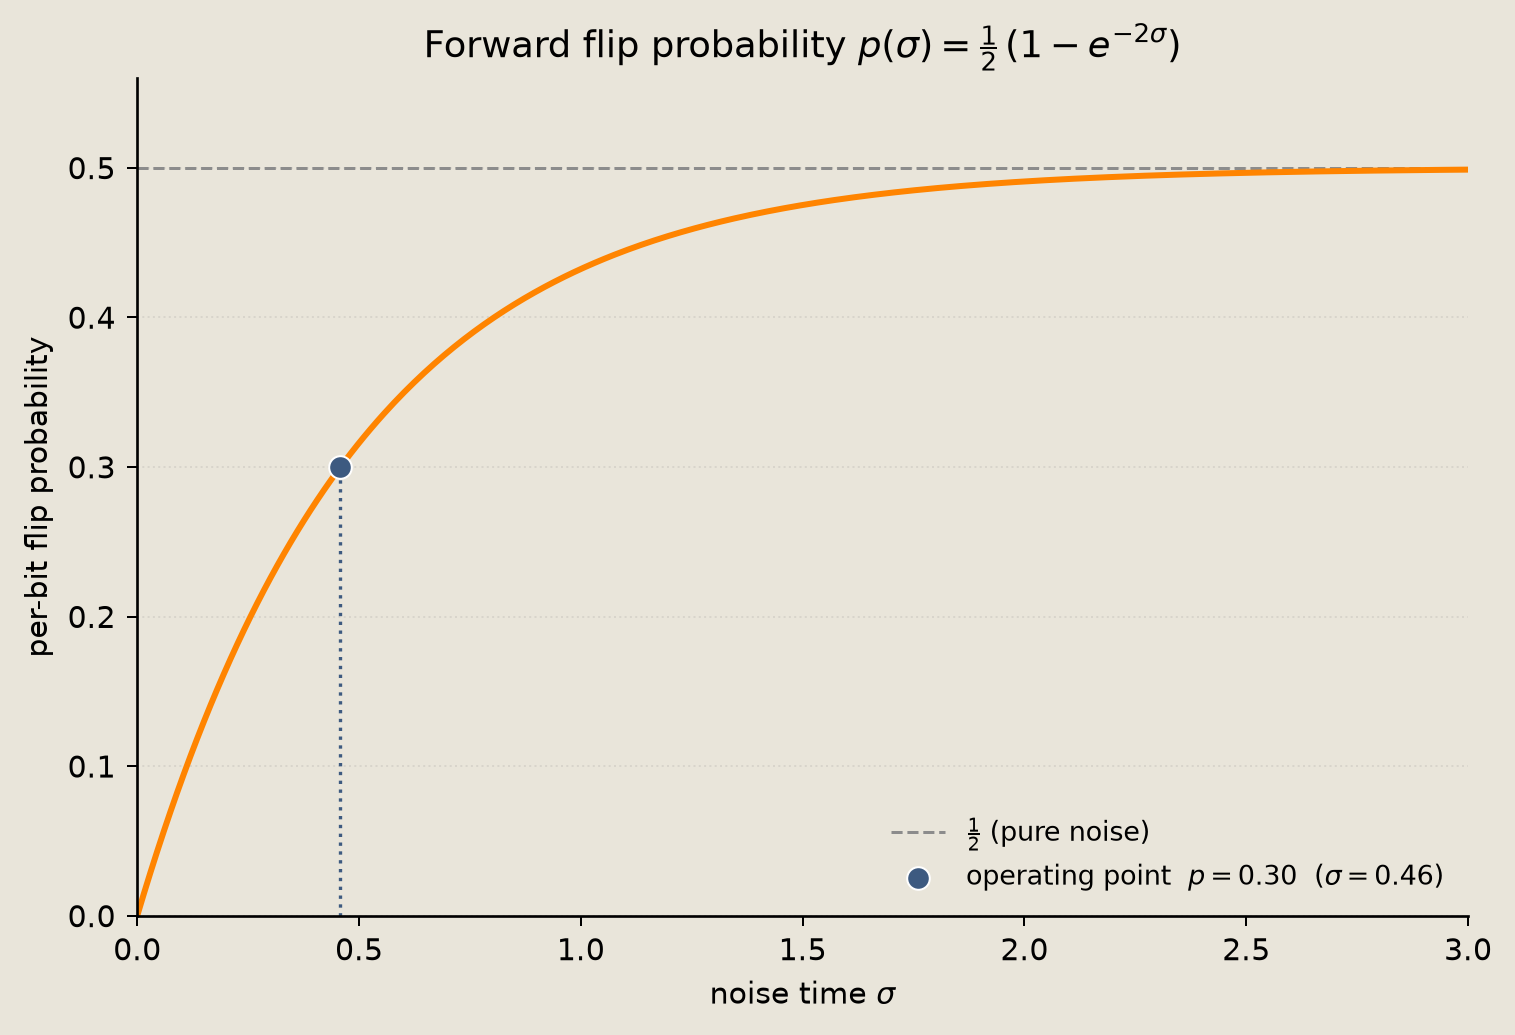

In [11]:
fig = plot_flip_probability(forward_p)
savefig(fig, "07_flip_probability")

The marked corruption level stays below the 0.5 pure-noise limit, so the corrupted images still carry enough signal for the reverse step.

## The denoiser

The denoiser supplies the per-pixel clean probabilities that drive every gate.

It is a UNet with 472k parameters: two downsampling blocks, a bottleneck, and two upsampling blocks with skip connections, each block two `GroupNorm`-normalized $3\times3$ convolutions. It was trained outside Torx on full binarized MNIST with a weighted binary cross-entropy, reading both the noisy pixels and the scalar noise level. Its per-pixel sigmoid output $\hat p_i$ is the probability that pixel $i$ is 1 in the clean image. The model definition and loader live in `examples/helpers/_nb07_diffusion.py`.

The reverse step flips bit $i$ with probability $p^{(i)}_{\text{flip}}$, set from the denoiser. A `PNOT` gate realizes that flip exactly when its parameter is the log-odds of flipping:

$$
\theta^{(i)} = \underbrace{\log \frac{p^{(i)}_{\text{flip}}}{1 - p^{(i)}_{\text{flip}}}}_{\vphantom{\big|}\text{log-odds}}, \qquad
p^{(i)}_{\text{flip}} = \begin{cases} 1 - \hat p_i & x_i = 1 \\ \hat p_i & x_i = 0. \end{cases}
$$

Here $\theta^{(i)}$ is the `PNOT` gate parameter and the log-odds is taken over flipping pixel $i$.

The cases point the flip toward the clean value predicted by the denoiser. If the pixel is currently 1, the flip probability is $1 - \hat p_i$, and if it is currently 0, the flip probability is $\hat p_i$.

## Training loss

Training ran offline for 30,000 gradient steps on GPU. We plot the loss curve loaded with the checkpoint above; the dashed line marks the final loss, where training stopped.

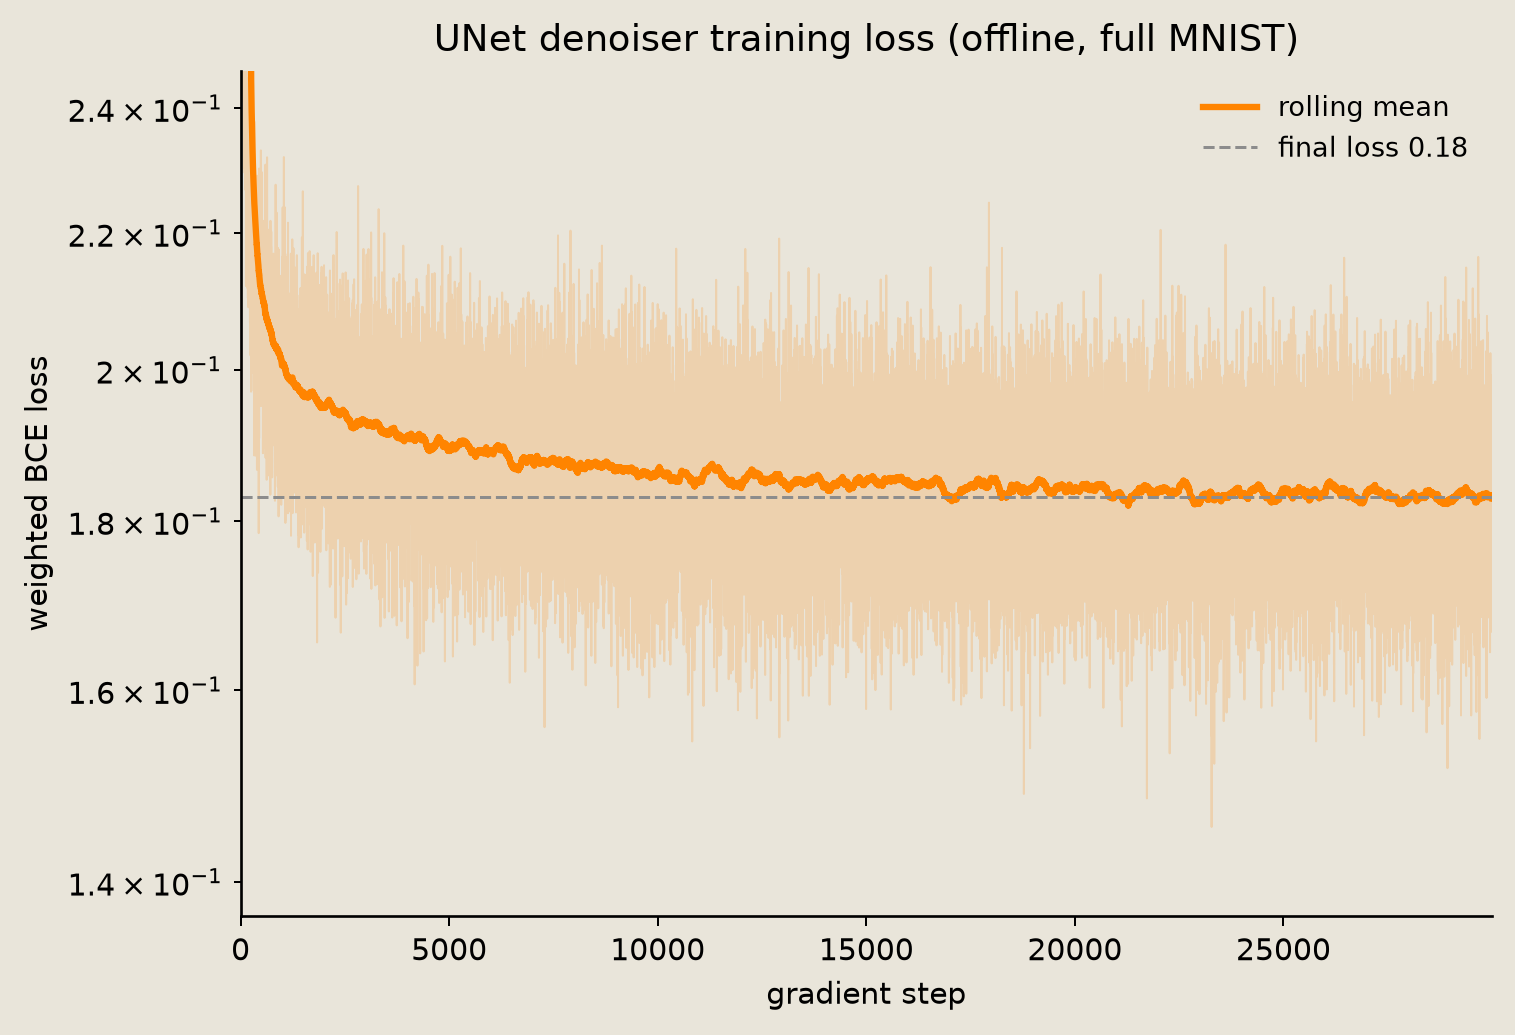

In [12]:
fig = plot_diffusion_loss(loss_history, reference_loss=meta["final_loss"])
savefig(fig, "07_diffusion_training_loss")

The loss flattens out, so the checkpoint is at convergence; the reconstructions below show how sharp its per-pixel probabilities are.

## The reverse circuit

One reverse step is one `PNOT` gate per pixel, with each gate's logit set from the denoiser as above. Flipping every pixel independently is tau-leaping: the whole image advances by one time step while each bit uses its own coin toss.

Independent flips lose the local correlations between neighboring pixels, which are part of what makes a digit look like a digit. Torx can restore that structure with two-site `PCNOT` gates, but only if each gate carries a coupling strength. The principled strength is a finite difference (the change in a quantity when one input is nudged) of the conditional flip probability:

$$
c_{j\to i} = \underbrace{p^{(i)}_{\text{flip}}(x_t \mid \bar{\jmath})}_{\vphantom{\big|}\text{flip if } j} - \underbrace{p^{(i)}_{\text{flip}}(x_t)}_{\vphantom{\big|}\text{flip as-is}},
$$

the difference between pixel $i$'s flip rate when neighbor $j$ is flipped and its flip rate as-is. One extra denoiser pass per neighbor-flipped image (batched, the same forward call this notebook already makes) would supply the $c_{j\to i}$. We keep `PCNOT` out of the executed reverse step: without the derived $c_{j\to i}$ a fixed-strength coupling is an arbitrary knob, and at a single step the per-pixel `PNOT` flips dominate anyway. Neighbor coupling becomes worthwhile only with the derived strengths or across many reverse steps, so this one-step tutorial runs `PNOT` alone.

The cell below wraps the helper's UNet forward pass, `denoise_logits`, into a per-pixel clean-probability function.

In [13]:
def predict_clean_probability(batch, sigma):
    """Per-pixel clean probabilities from the offline-trained UNet."""
    # the denoiser reads both the noisy pixels and the current noise level
    logits = denoise_logits(params, batch.astype(np.float32), sigma)
    return np.asarray(jax.nn.sigmoid(logits))

This compact four-wire circuit shows the gate pattern used by one reverse step.

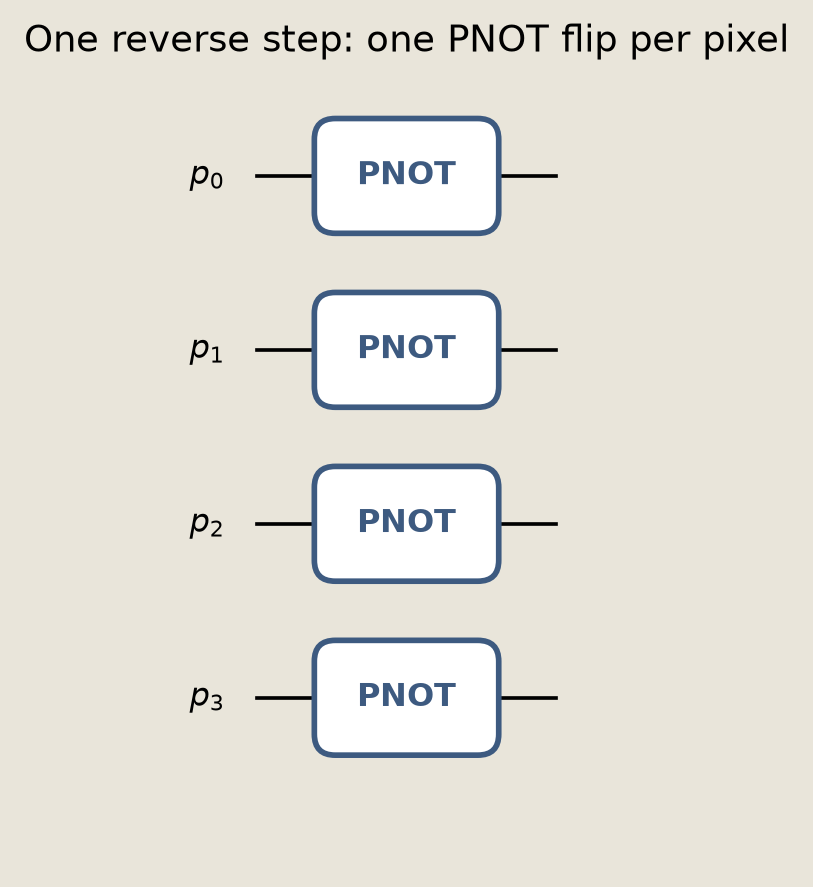

In [14]:
demo_specs = [
    ("PNOT", [0]),
    ("PNOT", [1]),
    ("PNOT", [2]),
    ("PNOT", [3]),
]
fig = draw_pcircuit(
    demo_specs,
    wire_labels=[r"$p_0$", r"$p_1$", r"$p_2$", r"$p_3$"],
    title="One reverse step: one PNOT flip per pixel",
)
savefig(fig, "07_reverse_circuit")

Each wire carries one independent `PNOT` flip. The full reverse step tiles this pattern across all 784 pixels, one gate per bit.

Now we assemble one reverse-step circuit template: one `PNOT` gate per pixel. We wrap the `vmap`-batched sampler in `eqx.filter_jit` with the template closed over, so the whole 784-pixel circuit compiles once and every image in the batch reuses it. We write the per-pixel logits into the template per row, and probabilities stay in `jnp` until the final reduction.

In [15]:
def torx_reverse(batch, *, seed_offset=0, num_samples=64):
    """Run one Torx reverse step and return per-pixel sample means."""
    x = batch.reshape(len(batch), -1).astype(np.int32)
    n_pixels = x.shape[1]
    sim = SampleSimulator(num_samples=num_samples)

    # gates are structure only; the per-gate flip logits live in `thetas`
    gates = [PNOT(i) for i in range(n_pixels)]
    # one (1,)-shaped theta per gate, aligned with `gates`, supplied at build
    init_thetas = [jnp.zeros((1,)) for _ in gates]
    template = sim.build_circuit(DiscretePCircuit(gates), init_thetas)

    def sample_one(row, row_p, row_key):
        # the PNOT flip logit is the log-odds of the per-pixel flip probability
        pnot_thetas = jnp.log(row_p / (1.0 - row_p))[:, None]
        compiled = eqx.tree_at(lambda c: c.thetas, template, pnot_thetas)
        return sim.sample(compiled, row, row_key).mean(axis=0)

    # jit the vmapped sampler over the closed-over template so the 784-gate
    # circuit compiles once and every image in the batch reuses it
    sample_batch = eqx.filter_jit(jax.vmap(sample_one))

    # forward_p is a per-bit flip prob; the UNet conditions on CTMC time sigma,
    # related by p = 0.5 * (1 - exp(-2 sigma)).
    sigma = -0.5 * float(np.log1p(-2 * forward_p))
    clean_prob = jnp.asarray(
        predict_clean_probability(x.reshape(len(batch), height, width), sigma)
    ).reshape(len(batch), -1)
    xj = jnp.asarray(x)
    # if a pixel is 1, flipping moves it toward 0; if 0, toward 1
    p_flip = jnp.clip(jnp.where(xj == 1, 1.0 - clean_prob, clean_prob), 0.001, 0.999)
    keys = jax.random.split(jax.random.key(SEED + seed_offset), len(x))
    # keep everything on device; convert to NumPy only for downstream plotting
    mean = sample_batch(xj, p_flip, keys)
    return np.asarray(mean).reshape(batch.shape)

In [16]:
tau_samples = torx_reverse(noisy, seed_offset=10)

In [17]:
tau_binary = (tau_samples >= 0.5).astype(np.int32)

In [18]:
forward_bit_error = float(np.mean(noisy != clean))
denoised_bit_error = float(np.mean(denoised != clean))
tau_bit_error = float(np.mean(tau_binary != clean))

assert tau_bit_error < forward_bit_error, (
    f"reverse step must reduce bit error: forward={forward_bit_error:.3f}, "
    f"tau={tau_bit_error:.3f}"
)

print(f"forward bit error: {forward_bit_error:.3f}")
print(f"UNet denoised:     {denoised_bit_error:.3f}")
print(f"Torx tau (PNOT):   {tau_bit_error:.3f}")

forward bit error: 0.301
UNet denoised:     0.058
Torx tau (PNOT):   0.083


## Sample grid

Each row shows the same eight digits at one stage: clean, forward-corrupted, the UNet denoise (the UNet's clean probabilities thresholded at 0.5), and the Torx reverse reconstruction. All images are native $28\times28$ binarized MNIST.

The Torx reconstruction is the binarized sample mean over 64 draws per pixel. The bit-error rates printed above quantify each stage. A single reverse step recovers clean digit structure and stays close to the UNet denoise in bit error (0.083 vs 0.058), though individual strokes can differ.

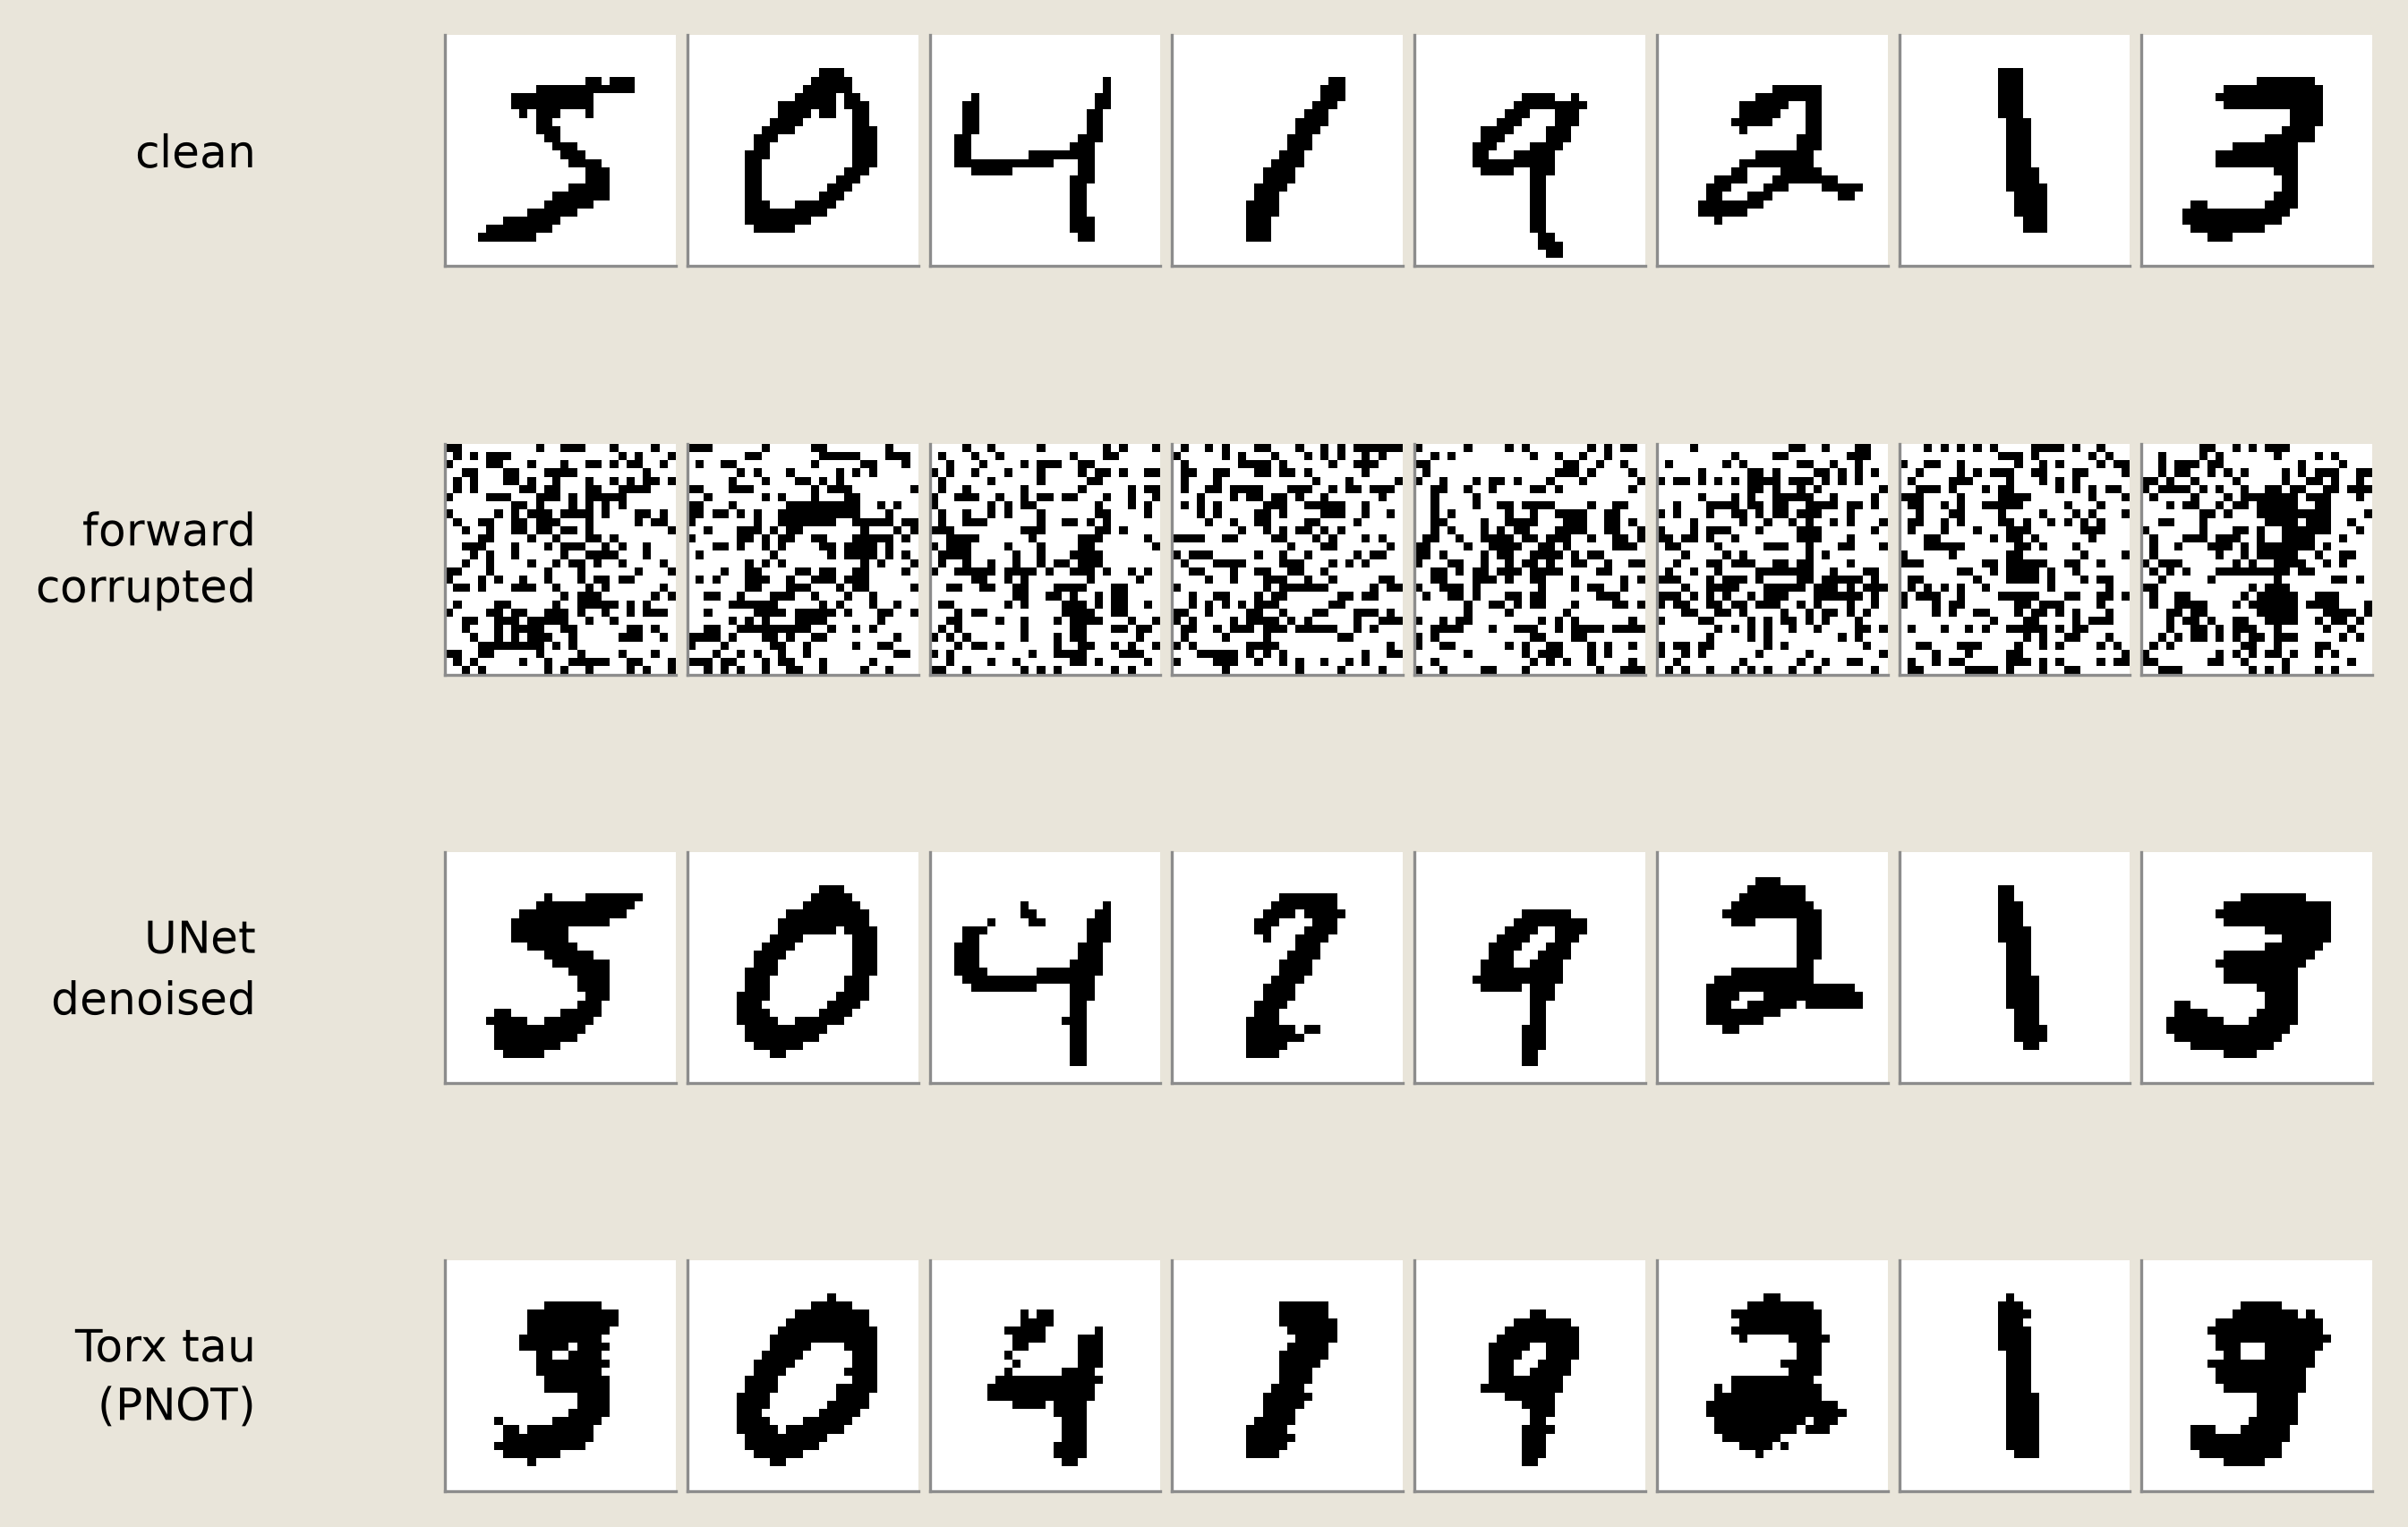

In [19]:
rows = [
    ("clean", clean),
    ("forward\ncorrupted", noisy),
    ("UNet\ndenoised", denoised),
    ("Torx tau\n(PNOT)", tau_binary),
]
fig = plot_reconstruction_grid(rows)
savefig(fig, "07_discrete_diffusion_samples")

The reconstruction cuts the bit-error rate well below the forward-corrupted input's, and the recovered digits look like real MNIST, though after heavy corruption a few come back as a different digit.

## Distribution quality

Bit-error rate says whether the reverse step flips the right pixels on average, and a step can pass that check while producing images that no longer look like digits. The standard check for whether the samples match the data distribution is the Fréchet inception distance, a distance between Gaussians fit to image features of the two sets.

On the full MNIST evaluation set the denoiser drops FID from 19.21 on the corrupted images to 2.63 on the denoised images, computed offline on GPU and reported from the checkpoint metadata. That drop is a committed training metric this notebook loads; the only FID it executes is the 64-image PCA-proxy direction check below, which recovers the sign of the drop but not its magnitude.

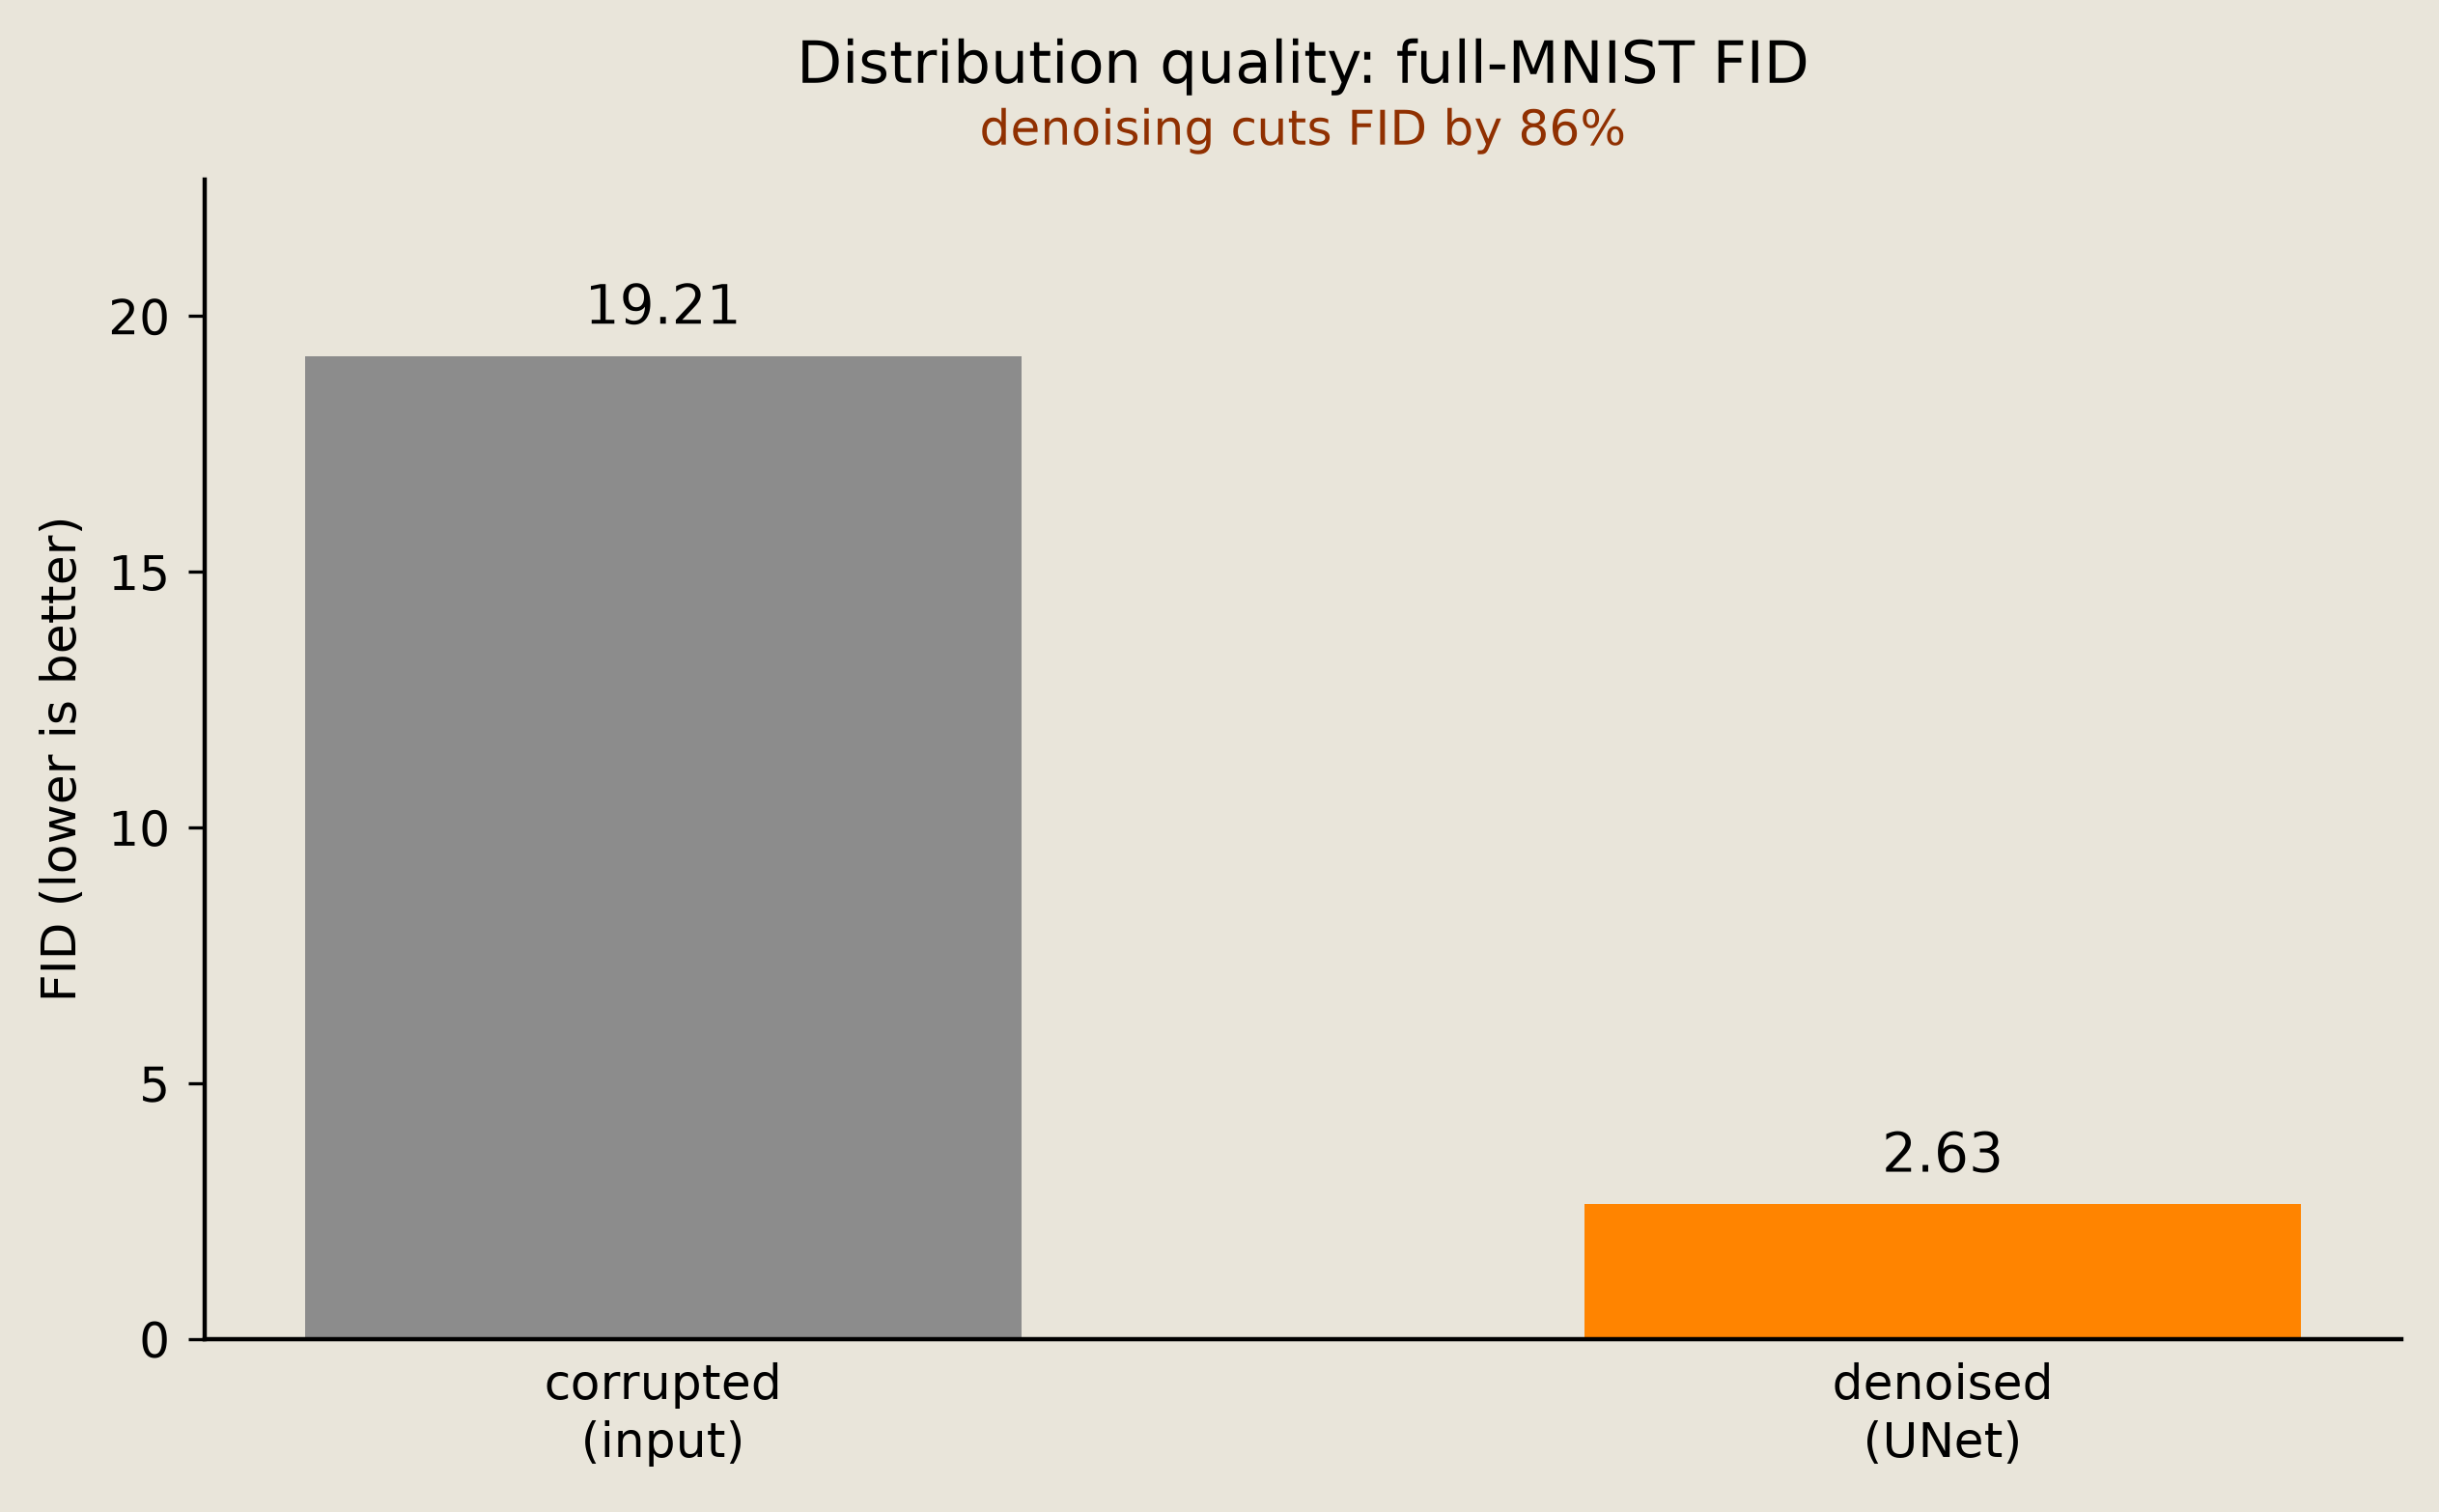

full-MNIST FID: corrupted 19.21 -> denoised 2.63


In [20]:
fig = plot_fid_drop(
    fid_corrupted=meta["fid_corrupted"],
    fid_denoised=meta["fid_denoised"],
)
savefig(fig, "07_discrete_diffusion_fid")
print(
    f"full-MNIST FID: corrupted {meta['fid_corrupted']:.2f} "
    f"-> denoised {meta['fid_denoised']:.2f}"
)

Standard FID reads Inception features, which need natural color photos. For $28\times28$ binary digits, the top 16 PCA components of the clean grids give a stand-in feature space; the `pca_features` and `frechet_distance` helpers in `examples/helpers/_nb07_diffusion.py` compute it. With only 64 committed grids and PCA fit on the clean split, this proxy can show the direction of the drop but cannot reproduce the full-MNIST Inception FID or bound it.

In [21]:
# directional cross-check with a PCA-feature proxy on the 64 committed grids;
# reference is a disjoint clean split so it does not include the eval images
feats = pca_features(clean_all, n_components=16, seed=SEED)
half = len(clean_all) // 2
f_ref = feats(clean_all[:half])
fid_clean_split = frechet_distance(f_ref, feats(clean_all[half:]))
fid_corrupt_proxy = frechet_distance(f_ref, feats(noisy_all))
fid_denoised_proxy = frechet_distance(f_ref, feats(denoised_all))

# a proxy on 64 grids cannot reproduce Inception FID, only its direction
assert fid_denoised_proxy < fid_corrupt_proxy

print("PCA-16 FID proxy (64 grids, not Inception FID)")
print(f"  clean vs held-out clean : {fid_clean_split:6.2f}")
print(f"  corrupted               : {fid_corrupt_proxy:6.2f}")
print(f"  denoised                : {fid_denoised_proxy:6.2f}")

PCA-16 FID proxy (64 grids, not Inception FID)
  clean vs held-out clean :  14.99
  corrupted               :  20.45
  denoised                :   7.05


The denoised samples sit well below the corrupted proxy value, consistent with the direction of the offline UNet-denoise FID drop. With 32-image splits the proxy is too noisy for anything beyond the direction of the change (the denoised value even lands below the clean-split baseline). This proxy check confirms only that the drop points the right way.

## Conclusion

We ran reverse diffusion on binarized MNIST with Torx stochastic circuits.

- One binary pixel is one pbit, so each reverse step on a $28\times28$ image is 784 `PNOT` gates, one independent flip per pixel.
- A UNet (472k params) trained offline on full MNIST to loss saturation supplies the per-pixel clean probability, which maps directly to a `PNOT` flip logit, so the network output sets every gate parameter without a hand-tuned schedule.
- The thresholded Torx reverse samples cut the bit error far below the corrupted input's and track the UNet denoise.
- Two-site `PCNOT` gates could reintroduce neighbor coupling, but without the derived $c_{j\to i}$ strengths a fixed coupling is an arbitrary knob, so we omit them here.
- The committed full-MNIST FID for the offline UNet denoise drops from 19.21 to 2.63, and a PCA-feature proxy on the committed grids moves in the same direction.

A natural next step is [`08_stochastic_convolutional_networks.ipynb`](08_stochastic_convolutional_networks.ipynb), which trains stochastic image circuits with parameter-shift gradients.

## References

1. Austin, J., Johnson, D.D., Ho, J., Tarlow, D., van den Berg, R. 2021. [*Structured denoising diffusion models in discrete state-spaces*](https://arxiv.org/abs/2107.03006). NeurIPS 34.
2. Campbell, A., Benton, J., De Bortoli, V., Rainforth, T., Deligiannidis, G., Doucet, A. 2022. [*A continuous time framework for discrete denoising models*](https://arxiv.org/abs/2205.14987). NeurIPS 35.

